<a href="https://colab.research.google.com/github/Anjana323/anjana323/blob/main/Decision_Tree_Gp4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving GROUP 4.xlsx to GROUP 4 (1).xlsx


In [ ]:
data = pd.read_excel("GROUP 4.xlsx", header=1)
data.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,12000,20000,1,2,2,30,1,2,0,0,...,17569,0,0,0,1200,406,0,0,0,1
1,12001,120000,1,1,2,37,-1,2,-1,-1,...,16885,46929,69521,0,316,16885,54629,77046,4499,0
2,12002,240000,2,1,2,27,0,0,0,0,...,166291,141380,130742,7058,6800,4050,6084,8028,4267,0
3,12003,80000,2,3,1,53,1,-1,-1,-2,...,0,0,496,1710,0,0,0,496,2560,1
4,12004,30000,1,2,1,35,1,-2,-2,-1,...,30821,30071,28767,0,0,35821,0,0,1000,0


In [ ]:
print(data.columns.tolist())

['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default payment next month']


In [ ]:
# define independent variables
X = data.drop("default payment next month", axis=1)

# define dependent variable
y = data["default payment next month"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=100
)

In [ ]:
model = DecisionTreeClassifier(
    max_depth=4,
    random_state=100
)

model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=100)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8039867109634552


The Decision Tree classifier achieved an accuracy of 80.39%, indicating that the model correctly classified approximately 80% of the observations in the test dataset. This suggests that the model has a reasonably good ability to distinguish between borrowers who will default and those who will not default.

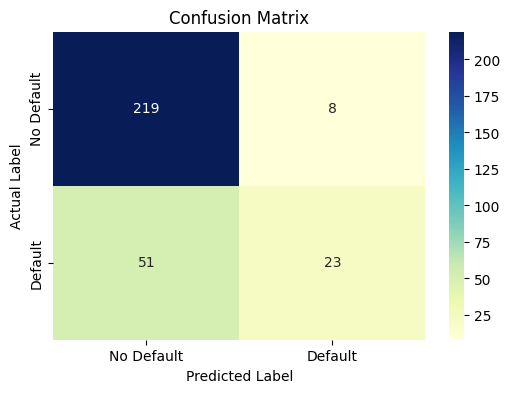

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

conf_matrix = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(conf_matrix,
                     index = ['No Default','Default'],
                     columns = ['No Default','Default'])

plt.figure(figsize=(6,4))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Confusion Matrix")
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

The confusion matrix shows the following classification results:

* 219 observations were correctly classified as No Default (True Negatives).
* 23 observations were correctly classified as Default (True Positives).
* 8 observations were incorrectly classified as Default when they were   actually No Default (False Positives).
* 51 observations were incorrectly classified as No Default when they were actually Default (False Negatives).

The relatively large number of false negatives (51) indicates that the model fails to detect a significant portion of borrowers who actually default.

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.96      0.88       227
           1       0.74      0.31      0.44        74

    accuracy                           0.80       301
   macro avg       0.78      0.64      0.66       301
weighted avg       0.79      0.80      0.77       301



In [ ]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(importance.head(10))

      Feature  Importance
5       PAY_0    0.654708
11  BILL_AMT1    0.071296
0   LIMIT_BAL    0.040418
9       PAY_5    0.038176
6       PAY_2    0.036963
22   PAY_AMT6    0.036079
19   PAY_AMT3    0.034932
16  BILL_AMT6    0.033597
3    MARRIAGE    0.030221
15  BILL_AMT5    0.023609


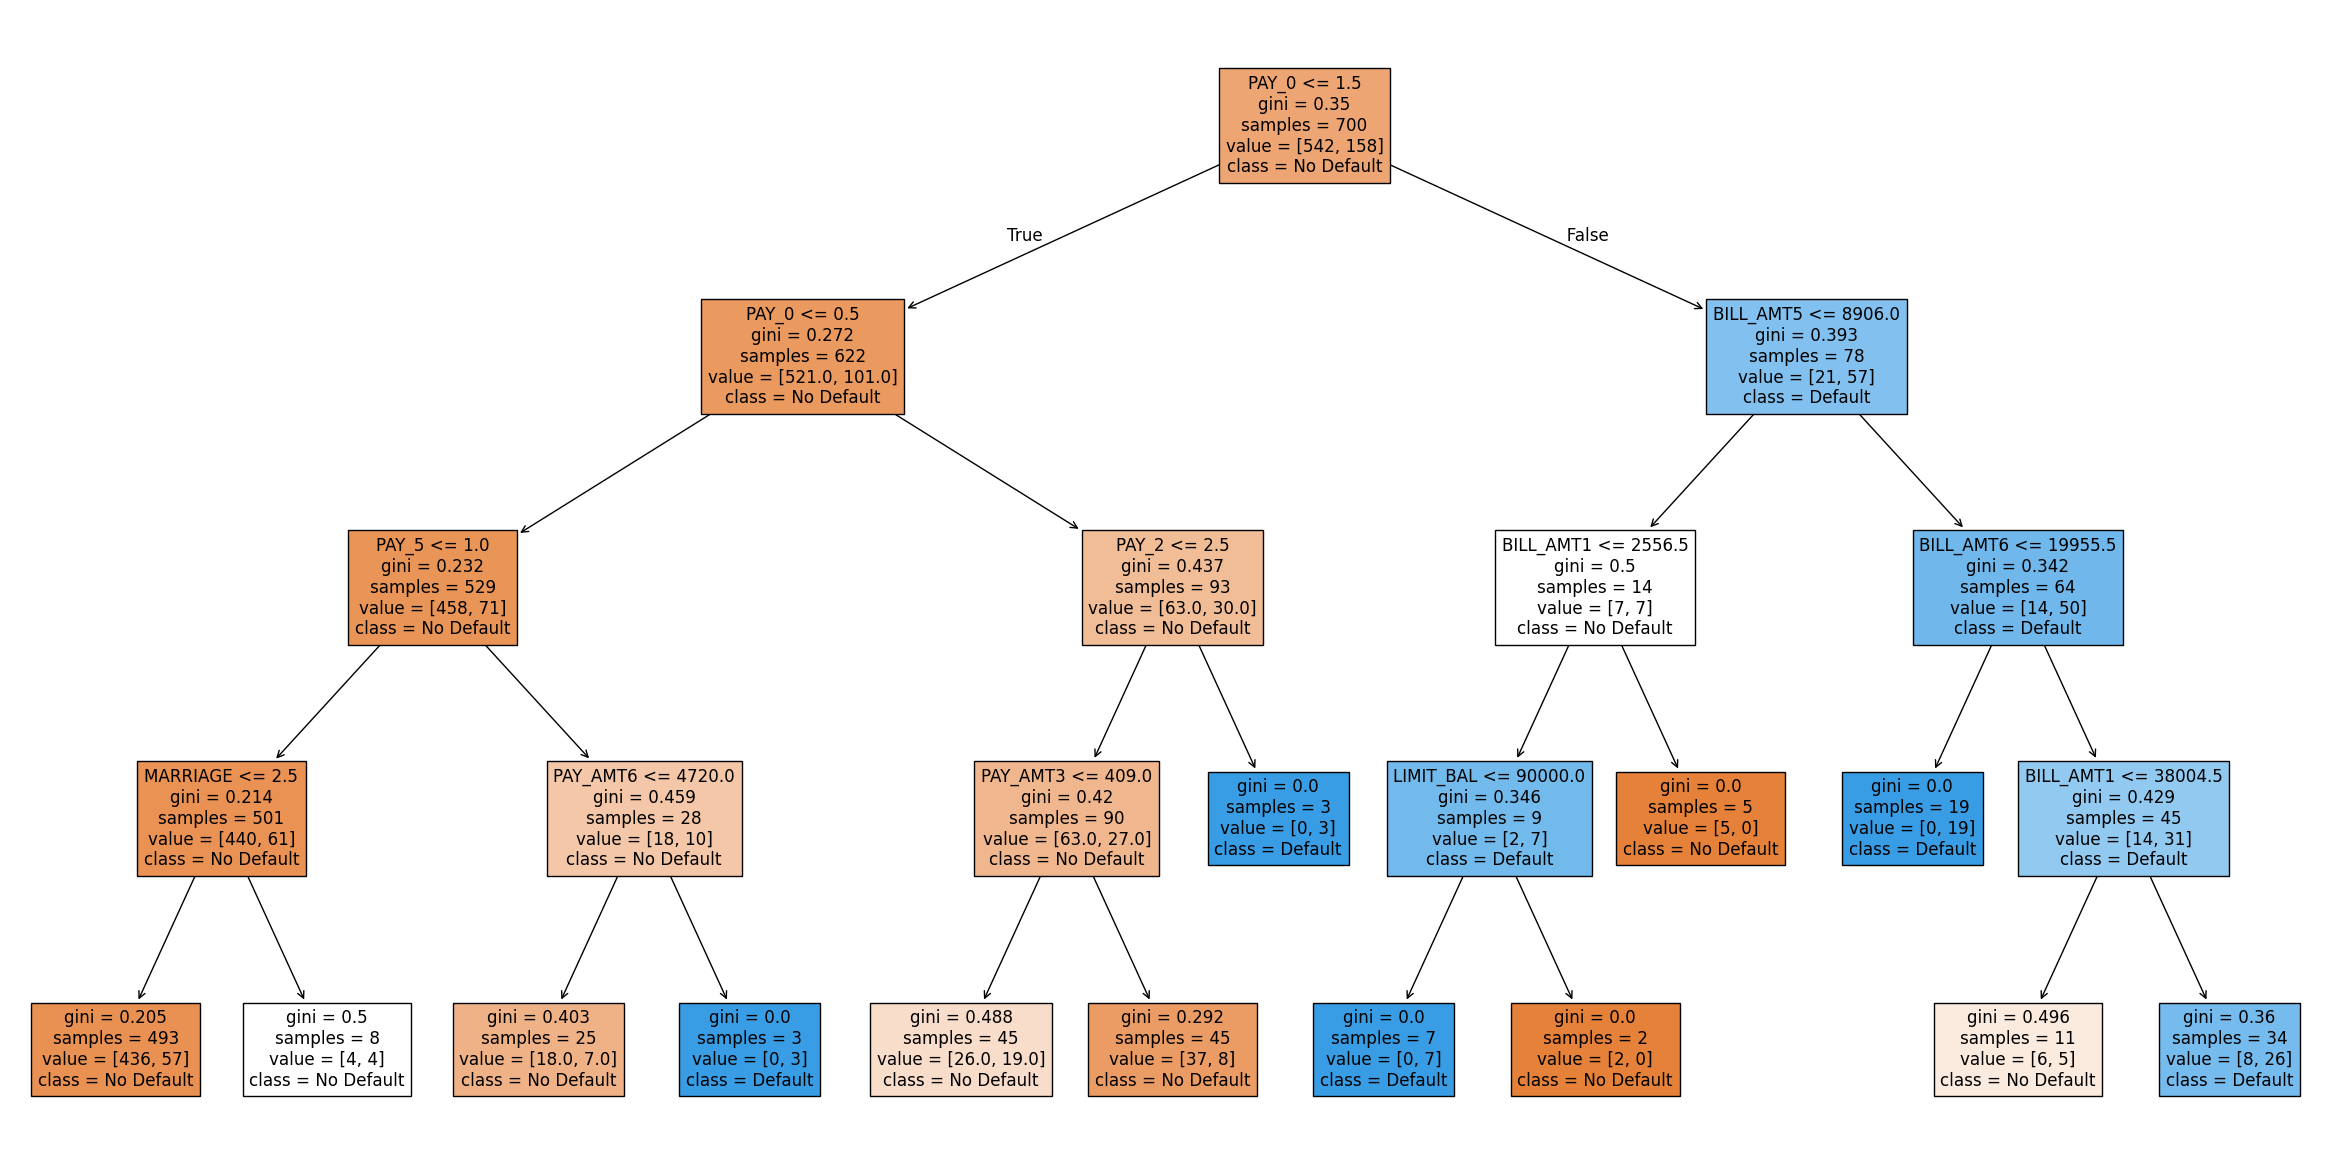

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(30,15))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["No Default","Default"],
    filled=True
)

plt.show()

# **INTERPRETATION**

The Decision Tree classifier was used to validate the probability of default (PD) model, and the results show an overall **accuracy of approximately 80.39%**, indicating that the model correctly classified about 80% of the observations in the test dataset. The confusion matrix reveals that **219 non-default cases and 23 default cases were correctly identified**, while **8 non-default cases were incorrectly classified as default and 51 default cases were misclassified as non-default**. The presence of a relatively large number of false negatives suggests that the model fails to identify a considerable portion of borrowers who actually default, which is an important limitation in credit risk prediction.

The classification report further highlights the model’s performance across the two classes. For the **non-default class**, the model shows strong performance with a **precision of 0.81 and recall of 0.96**, indicating that it correctly identifies most borrowers who do not default. However, the performance for the **default class is weaker**, with a **precision of 0.74 and recall of only 0.31**, meaning that the model detects only a small proportion of actual defaulters. This indicates that although the model is reasonably accurate when predicting default, it misses many risky borrowers.

The feature importance and decision tree structure indicate that **recent repayment behaviour (PAY_0)** is the most influential variable in predicting default risk, followed by variables such as **bill amount and credit limit**. The tree structure shows that repayment history plays a key role in classifying borrowers into default and non-default categories. Overall, while the Decision Tree model provides useful insights and achieves good overall accuracy, its ability to identify default cases remains limited, suggesting that further improvements or alternative models may be necessary to enhance the detection of credit risk.
